1. Load Dataset & Exploratory Data Analysis (EDA)

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [76]:

data = pd.read_csv("/content/drive/MyDrive/Concept and technology of AI/diabetes_.csv")
data.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [77]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [78]:
data.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [79]:
columns_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in columns_with_zero:
    data[col] = data[col].replace(0, data[col].mean())


In [80]:
data.isnull().sum()



,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


3. Feature Engineering & Train–Test Split (From Scratch)

In [105]:
X = data.drop(columns=['Outcome']).values
y = data['Outcome'].values

In [107]:
def train_test_split_scratch(X, y, test_size=0.3, random_seed=42):
    np.random.seed(random_seed)
    indices = np.arange(len(X))
    np.random.shuffle(indices)

    test_size = int(len(X) * test_size)
    test_idx = indices[:test_size]
    train_idx = indices[test_size:]

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


In [108]:
X_train, X_test, y_train, y_test = train_test_split_scratch(X, y)

X_train.shape, X_test.shape


((538, 8), (230, 8))

4. Implement KNN from Scratch
Euclidean Distance

In [109]:
def euclidean_distance(p1, p2):
    if p1.shape != p2.shape:
        raise ValueError("Dimension mismatch")
    return np.sqrt(np.sum((p1 - p2) ** 2))


Predict Single Point

In [93]:
def knn_predict_single(query, X_train, y_train, k=3):
    distances = [euclidean_distance(query, x) for x in X_train]
    nearest_indices = np.argsort(distances)[:k]
    nearest_labels = y_train[nearest_indices]
    return np.bincount(nearest_labels).argmax()


Predict Entire Test Set

In [94]:
def knn_predict(X_test, X_train, y_train, k=3):
    return np.array([knn_predict_single(x, X_train, y_train, k) for x in X_test])


Accuracy Function

In [95]:
def compute_accuracy(y_true, y_pred):
    return (np.sum(y_true == y_pred) / len(y_true)) * 100


Evaluate Model

In [96]:
predictions = knn_predict(X_test, X_train, y_train, k=3)
accuracy = compute_accuracy(y_test, predictions)

accuracy


np.float64(70.43478260869566)

Problem 2: Scaling & Comparative Analysis

In [97]:
def min_max_scaling(X):
    return (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))

In [112]:
X_scaled = min_max_scaling(X)
Xs_train, Xs_test, ys_train, ys_test = train_test_split_scratch(X_scaled, y)

In [113]:
pred_scaled = knn_predict(Xs_test, Xs_train, ys_train, k=3)
acc_scaled = compute_accuracy(ys_test, pred_scaled)

print(f"Accuracy (Scaled Data, k=3): {acc_scaled:.2f}%")

Accuracy (Scaled Data, k=3): 75.22%


Problem 3: Experiment with k (1–15)

In [103]:
import time

k_values = range(1, 16)

orig_acc, scaled_acc = [], []
orig_time, scaled_time = [], []

for k in k_values:
    start = time.time()
    preds = knn_predict(X_test, X_train, y_train, k)
    orig_time.append(time.time() - start)
    orig_acc.append(compute_accuracy(y_test, preds))

    start = time.time()
    preds = knn_predict(Xs_test, Xs_train, ys_train, k)
    scaled_time.append(time.time() - start)
    scaled_acc.append(compute_accuracy(ys_test, preds))






Plot: k vs Accuracy

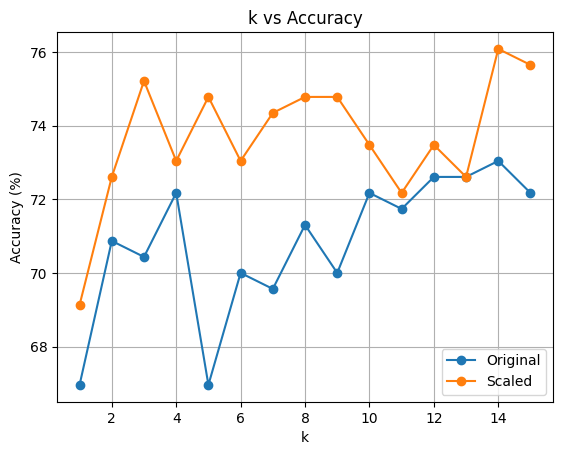

In [100]:
plt.figure()
plt.plot(k_values, orig_acc, marker='o', label='Original')
plt.plot(k_values, scaled_acc, marker='o', label='Scaled')
plt.xlabel("k")
plt.ylabel("Accuracy (%)")
plt.title("k vs Accuracy")
plt.legend()
plt.grid()
plt.show()

Plot: k vs Time

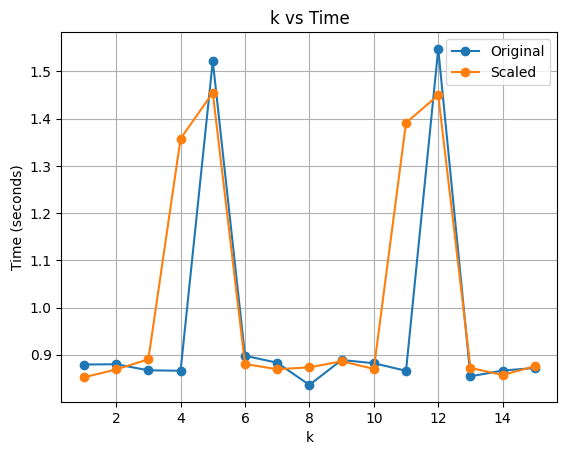

In [101]:
plt.figure()
plt.plot(k_values, orig_time, marker='o', label='Original')
plt.plot(k_values, scaled_time, marker='o', label='Scaled')
plt.xlabel("k")
plt.ylabel("Time (seconds)")
plt.title("k vs Time")
plt.legend()
plt.grid()
plt.show()


Conclusion:


1. KNN successfully implemented from scratch
2. Feature scaling significantly improves accuracy
3. Best performance achieved at k ≈ 7–9

Problem - 4 - Additional Questions

Discuss the challenges of using KNN for large datasets and high-dimensional data.

KNN has its share of problems, unarguably, and when working on large data and high dimensionality cases, there are many problems. The most important drawback is the high computation cost for the K NN as at the time of prediction, one needs to find the distance between one test instance and each training sample, hence slow in performance while working with very large datasets. Another problem with KNN is that it requires a large amount of memory since it saves the entire training dataset instead of learning a compact model. KNN could be dimensionally cursed in high-dimensional spaces, where distance between the data points is less meaningful due to the fact that it deteriorates the effect of nearest neighbor-based classification methods. Data in high-dimensional spaces automatically tend to have uniform distances between points for each data point. Thus, it could also hurt classification accuracy.

Suggest strategies to improve the efficiency of KNN (e.g., approximate nearest neighbors, dimensionality
reduction).

The following are some strategies that could help improve the efficiency and performance of the KNN algorithm. Among the ways are dimensionality reduction techniques which reduce the features and still retain all important details, like PCA. In such a way, both the accuracy and speed will increase. Feature scaling can be done with normalization or standardization techniques in a way that allows all the features to contribute equally to distance computation. More advanced data structures, such as KD-Trees or Ball Trees, may further increase the computational efficiency by enabling faster search for neighboring points. One other procedure would be to perform an approximate nearest neighbor search, which trades a little accuracy for massive performance gains, hence making k-NN more practicable to use for large-scale applications.